In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as transforms
from PIL import Image
import os
from tqdm import tqdm

# ==========================================
# 1. Dataset Loader (Back to stable 3-channel)
# ==========================================
class GANStitchedDataset(Dataset):
    def __init__(self, root_dir):
        self.root_dir = root_dir
        self.files = sorted([f for f in os.listdir(root_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
        self.transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
        ])

    def __len__(self): return len(self.files)

    def __getitem__(self, idx):
        img_path = os.path.join(self.root_dir, self.files[idx])
        img = Image.open(img_path).convert("RGB") # Keep target RGB!
        w, h = img.size
        cluttered = img.crop((0, 0, w // 2, h))
        clean = img.crop((w // 2, 0, w, h))
        return self.transform(cluttered), self.transform(clean)

# ==========================================
# 2. Generator (Stable ConvTranspose2d)
# ==========================================
class UNetDown(nn.Module):
    def __init__(self, in_size, out_size, normalize=True, dropout=0.0):
        super().__init__()
        layers = [nn.Conv2d(in_size, out_size, 4, 2, 1, bias=False)]
        if normalize: layers.append(nn.InstanceNorm2d(out_size))
        layers.append(nn.LeakyReLU(0.2))
        if dropout: layers.append(nn.Dropout(dropout))
        self.model = nn.Sequential(*layers)
    def forward(self, x): return self.model(x)

class UNetUp(nn.Module):
    def __init__(self, in_size, out_size, dropout=0.0):
        super().__init__()
        layers = [
            nn.ConvTranspose2d(in_size, out_size, 4, 2, 1, bias=False),
            nn.InstanceNorm2d(out_size),
            nn.ReLU(inplace=True)
        ]
        if dropout: layers.append(nn.Dropout(dropout))
        self.model = nn.Sequential(*layers)
    def forward(self, x, skip_input): return torch.cat((self.model(x), skip_input), 1)

class GeneratorUNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.down1 = UNetDown(3, 64, normalize=False)
        self.down2 = UNetDown(64, 128)
        self.down3 = UNetDown(128, 256)
        self.down4 = UNetDown(256, 512, dropout=0.5)
        self.down5 = UNetDown(512, 512, dropout=0.5)
        self.down6 = UNetDown(512, 512, dropout=0.5)
        self.down7 = UNetDown(512, 512, dropout=0.5)
        self.down8 = UNetDown(512, 512, normalize=False)

        self.up1 = UNetUp(512, 512, dropout=0.5)
        self.up2 = UNetUp(1024, 512, dropout=0.5)
        self.up3 = UNetUp(1024, 512, dropout=0.5)
        self.up4 = UNetUp(1024, 512, dropout=0.5)
        self.up5 = UNetUp(1024, 256)
        self.up6 = UNetUp(512, 128)
        self.up7 = UNetUp(256, 64)

        self.final = nn.Sequential(
            nn.ConvTranspose2d(128, 3, 4, 2, 1),
            nn.Tanh() # Outputs 3 channels
        )

    def forward(self, x):
        d1 = self.down1(x); d2 = self.down2(d1); d3 = self.down3(d2); d4 = self.down4(d3)
        d5 = self.down5(d4); d6 = self.down6(d5); d7 = self.down7(d6); d8 = self.down8(d7)
        u1 = self.up1(d8, d7); u2 = self.up2(u1, d6); u3 = self.up3(u2, d5); u4 = self.up4(u3, d4)
        u5 = self.up5(u4, d3); u6 = self.up6(u5, d2); u7 = self.up7(u6, d1)
        return self.final(u7)

# ==========================================
# 3. Discriminator & Custom Losses
# ==========================================
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(6, 64, 4, 2, 1), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, 4, 2, 1), nn.InstanceNorm2d(128), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(128, 256, 4, 2, 1), nn.InstanceNorm2d(256), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(256, 1, 4, 1, 1)
        )
    def forward(self, x, y): return self.model(torch.cat([x, y], dim=1))

def gan_dice_loss(pred, target, smooth=1e-5):
    pred_soft, target_soft = (pred + 1) / 2, (target + 1) / 2
    pred_flat, target_flat = pred_soft.view(-1), target_soft.view(-1)
    intersection = (pred_flat * target_flat).sum()
    return 1 - ((2. * intersection + smooth) / (pred_flat.sum() + target_flat.sum() + smooth))

# THE NEW SECRET WEAPON: Grayscale Penalty
def color_penalty(pred):
    # Penalize the difference between Red, Green, and Blue channels
    r, g, b = pred[:, 0, :, :], pred[:, 1, :, :], pred[:, 2, :, :]
    rg_diff = torch.mean(torch.abs(r - g))
    gb_diff = torch.mean(torch.abs(g - b))
    rb_diff = torch.mean(torch.abs(r - b))
    return rg_diff + gb_diff + rb_diff

# ==========================================
# 4. Training Loop
# ==========================================
DATA_DIR = "gan_stitched" 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

gen = nn.DataParallel(GeneratorUNet()).to(device)
disc = nn.DataParallel(Discriminator()).to(device)

# Keep the TTUR rates that gave us the successful trace
opt_gen = optim.Adam(gen.parameters(), lr=2e-4, betas=(0.5, 0.999))
opt_disc = optim.Adam(disc.parameters(), lr=5e-5, betas=(0.5, 0.999)) 

criterion_GAN = nn.MSELoss() 
criterion_pixelwise = nn.L1Loss() 

train_loader = DataLoader(GANStitchedDataset(DATA_DIR), batch_size=32, shuffle=True, pin_memory=True)

for epoch in range(50):
    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/50")
    for x, y in loop:
        x, y = x.to(device), y.to(device)
        
        # Train Discriminator
        fake_y = gen(x)
        loss_d = (criterion_GAN(disc(x, y), torch.ones_like(disc(x, y))) + 
                  criterion_GAN(disc(x, fake_y.detach()), torch.zeros_like(disc(x, fake_y.detach())))) / 2
        
        opt_disc.zero_grad()
        loss_d.backward()
        opt_disc.step()

        # Train Generator
        loss_g_gan = criterion_GAN(disc(x, fake_y), torch.ones_like(disc(x, fake_y)))
        loss_g_pixel = criterion_pixelwise(fake_y, y) * 10
        loss_g_dice = gan_dice_loss(fake_y, y) * 50
        
        # APPLY HEAVY COLOR PENALTY TO FORCE GRAYSCALE
        loss_g_color = color_penalty(fake_y) * 100 
        
        loss_g = loss_g_gan + loss_g_pixel + loss_g_dice + loss_g_color
        
        opt_gen.zero_grad()
        loss_g.backward()
        opt_gen.step()
        
        loop.set_postfix(D=loss_d.item(), G=loss_g.item(), Color=loss_g_color.item())
        
    if (epoch + 1) % 10 == 0:
        torch.save(gen.module.state_dict(), f"color_crusher_gan_epoch_{epoch+1}.pth")

Epoch 50/50: 100%|██████████| 45/45 [00:14<00:00,  3.10it/s, Color=0.132, D=0.00117, G=35.7] 


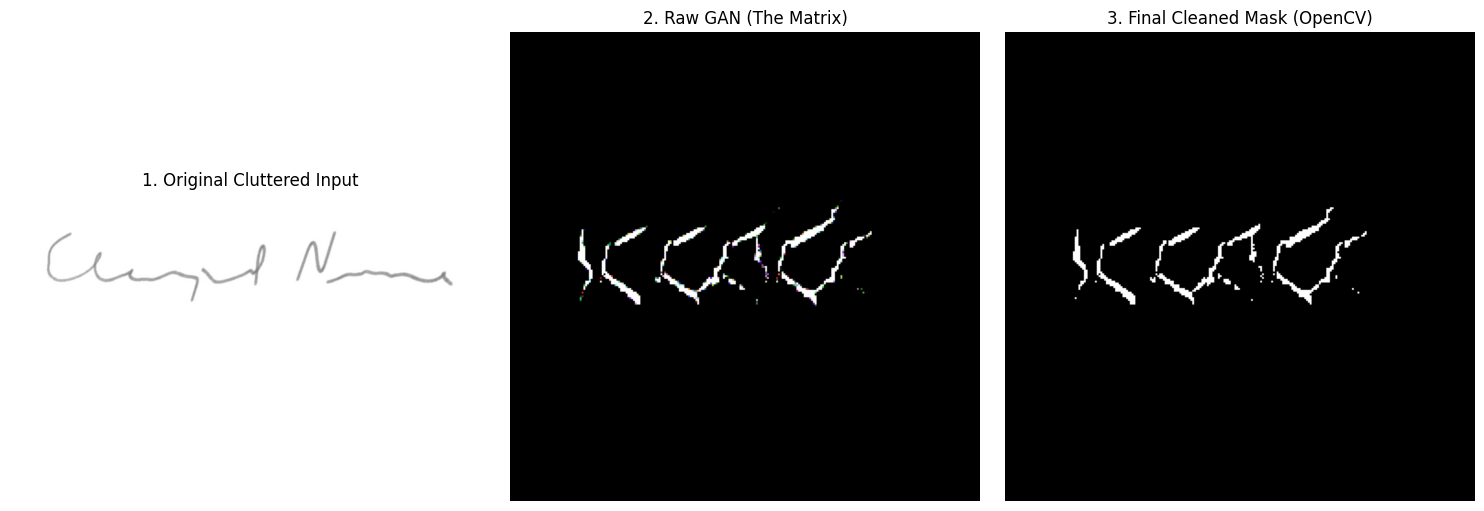

In [8]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt
import cv2
import numpy as np

# ==========================================
# 1. The ORIGINAL Advanced GAN Architecture (With BatchNorm)
# ==========================================
class UNetDown(nn.Module):
    def __init__(self, in_size, out_size, normalize=True, dropout=0.0):
        super().__init__()
        layers = [nn.Conv2d(in_size, out_size, 4, 2, 1, bias=False)]
        if normalize:
            layers.append(nn.BatchNorm2d(out_size)) # THE FIX: Back to BatchNorm
        layers.append(nn.LeakyReLU(0.2))
        if dropout:
            layers.append(nn.Dropout(dropout))
        self.model = nn.Sequential(*layers)
    def forward(self, x): return self.model(x)

class UNetUp(nn.Module):
    def __init__(self, in_size, out_size, dropout=0.0):
        super().__init__()
        layers = [
            nn.ConvTranspose2d(in_size, out_size, 4, 2, 1, bias=False),
            nn.BatchNorm2d(out_size), # THE FIX: Back to BatchNorm
            nn.ReLU(inplace=True)
        ]
        if dropout:
            layers.append(nn.Dropout(dropout))
        self.model = nn.Sequential(*layers)
    def forward(self, x, skip_input):
        return torch.cat((self.model(x), skip_input), 1)

class GeneratorUNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.down1 = UNetDown(3, 64, normalize=False)
        self.down2 = UNetDown(64, 128)
        self.down3 = UNetDown(128, 256)
        self.down4 = UNetDown(256, 512, dropout=0.5)
        self.down5 = UNetDown(512, 512, dropout=0.5)
        self.down6 = UNetDown(512, 512, dropout=0.5)
        self.down7 = UNetDown(512, 512, dropout=0.5)
        self.down8 = UNetDown(512, 512, normalize=False)

        self.up1 = UNetUp(512, 512, dropout=0.5)
        self.up2 = UNetUp(1024, 512, dropout=0.5)
        self.up3 = UNetUp(1024, 512, dropout=0.5)
        self.up4 = UNetUp(1024, 512, dropout=0.5)
        self.up5 = UNetUp(1024, 256)
        self.up6 = UNetUp(512, 128)
        self.up7 = UNetUp(256, 64)

        self.final = nn.Sequential(
            nn.ConvTranspose2d(128, 3, 4, 2, 1),
            nn.Tanh()
        )

    def forward(self, x):
        d1 = self.down1(x); d2 = self.down2(d1); d3 = self.down3(d2); d4 = self.down4(d3)
        d5 = self.down5(d4); d6 = self.down6(d5); d7 = self.down7(d6); d8 = self.down8(d7)
        u1 = self.up1(d8, d7); u2 = self.up2(u1, d6); u3 = self.up3(u2, d5); u4 = self.up4(u3, d4)
        u5 = self.up5(u4, d3); u6 = self.up6(u5, d2); u7 = self.up7(u6, d1)
        return self.final(u7)

# ==========================================
# 2. Load the Weights & Run Inference
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
best_gen = GeneratorUNet().to(device) 

# NOW it will load perfectly!
best_gen.load_state_dict(torch.load("advanced_gan_epoch_50.pth", map_location=device))
best_gen.eval()

transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

def ultimate_inference_with_cv(image_path):
    img = Image.open(image_path).convert("RGB")
    x = transform(img).unsqueeze(0).to(device)
    
    with torch.no_grad():
        generated = best_gen(x)
        
    generated = generated.squeeze(0).cpu() 
    generated = generated * 0.5 + 0.5 
    
    gen_np = generated.permute(1, 2, 0).clamp(0, 1).numpy()
    gen_np = (gen_np * 255).astype(np.uint8)
    
    # --- OpenCV Post-Processing ---
    gray = cv2.cvtColor(gen_np, cv2.COLOR_RGB2GRAY)
    _, binary_mask = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    
    # --- Plotting ---
    plt.figure(figsize=(15, 5))
    
    plt.subplot(1, 3, 1)
    plt.title("1. Original Cluttered Input")
    plt.imshow(img)
    plt.axis('off')
    
    plt.subplot(1, 3, 2)
    plt.title("2. Raw GAN (The Matrix)")
    plt.imshow(gen_np)
    plt.axis('off')
    
    plt.subplot(1, 3, 3)
    plt.title("3. Final Cleaned Mask (OpenCV)")
    plt.imshow(binary_mask, cmap='gray')
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

# --- RUN THE TEST ---
TEST_IMAGE = "cutouts/0039__cf-039-51_cutout.png" 
ultimate_inference_with_cv(TEST_IMAGE)